# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# =========================================================
# CLEAN IMPORTS (DEDUPED) — ALBERT soft training + tuning + evaluation (CI + plots)
# =========================================================

# --- Standard library ---
import os
import re
import json
import time
import string
import random
import itertools
import warnings
from pathlib import Path
from collections import Counter

# --- Core DS stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Scikit-learn ---
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# --- Transformers ---
from transformers import AutoTokenizer, AlbertModel, AlbertForSequenceClassification

# --- Persistence ---
import joblib

# --- Optional (ONLY if you actually use them) ---
# from wordcloud import WordCloud
# from statsmodels.stats.contingency_tables import mcnemar
# from statsmodels.stats.multitest import multipletests
# import nltk
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize
# from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

# --- Notebook setup ---
%matplotlib inline
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# NLTK downloads (uncomment only if needed)
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("punkt")

Device: cuda


## 1.2 Configuration

In [6]:
import os
from pathlib import Path

# --- 1. Project & Path Settings ---
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini"
RAW_DATA_FILE = "data/hatexplain_model_ready_with_ai_labels.csv"

# Output directory (inside project)
OUTPUT_DIR = "output"

# Filenames for your trained model artifacts
ALBERT_MODEL_FILE = "best_albert_model_T51.pth"
ALBERT_PARAMS_FILE = "best_albert_params_soft_4omini_T51.json"

# --- 2. Dataset & Label Settings (SOFT LABELS ONLY: 4o-mini) ---
TEXT_COLUMN = "text"

# Class order MUST match your probability columns
CLASS_NAMES = ["normal", "offensive", "hate"]
N_CLASSES = len(CLASS_NAMES)

# Soft-label probability columns (must align with CLASS_NAMES order above)
SOFT_LABEL_COLUMNS = ["ai_p_normal_mini", "ai_p_offensive_mini", "ai_p_hate_mini"]

EXPECTED_LABEL_SOURCE = "ai_4omini"
LABEL_MODE = "soft"

# --- 3. Training & Tokenizer Settings ---
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42

# --- 4. Full Paths (Auto-generated) ---
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

BEST_ALBERT_PATH = OUTPUT_PATH / ALBERT_MODEL_FILE
BEST_ALBERT_PARAMS_PATH = OUTPUT_PATH / ALBERT_PARAMS_FILE

print("--- Configuration Loaded (4o-mini soft labels | ALBERT) ---")
print(f"Project Path: {DRIVE_PROJECT_PATH}")
print(f"Raw Data Path: {RAW_DATA_PATH}")
print(f"Output Path: {OUTPUT_PATH}")
print(f"Label mode/source: {LABEL_MODE} / {EXPECTED_LABEL_SOURCE}")
print(f"Soft label cols: {SOFT_LABEL_COLUMNS}")
print(f"ALBERT Model Path: {BEST_ALBERT_PATH}")
print(f"ALBERT Params Path: {BEST_ALBERT_PARAMS_PATH}")

--- Configuration Loaded (4o-mini soft labels | ALBERT) ---
Project Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini
Raw Data Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/data/hatexplain_model_ready_with_ai_labels.csv
Output Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output
Label mode/source: soft / ai_4omini
Soft label cols: ['ai_p_normal_mini', 'ai_p_offensive_mini', 'ai_p_hate_mini']
ALBERT Model Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/best_albert_model_T51.pth
ALBERT Params Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/best_albert_params_soft_4omini_T51.json


## 1.3 Load the data

In [7]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [8]:
# Load the raw data from our config path into a generic DataFrame
df_raw = pd.read_csv(RAW_DATA_PATH, index_col = 0)
print(f"Loaded raw data with {df_raw.shape[0]} rows.")

df_raw.head()

Loaded raw data with 20148 rows.


,text,label_id1,label_id2,label_id3,human_majority,is_pure,human_pure,ai_label_mini,ai_label_text_mini,ai_p_normal_mini,ai_p_offensive_mini,ai_p_hate_mini
id,,,,,,,,,,,,
1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.90,0.1,0.00
1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.85,0.1,0.05
1178793830532956161_twitter,nawt yall niggers ignoring me,normal,normal,hatespeech,normal,False,NaN,HATE,hatespeech,0.00,0.1,0.90
1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech,offensive,hatespeech,hatespeech,False,NaN,HATE,hatespeech,0.00,0.2,0.80
1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech,hatespeech,offensive,hatespeech,False,NaN,HATE,hatespeech,0.00,0.1,0.90


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [9]:
df_raw.shape

(20148, 12)

## 2.2 Master Data Preparation

In [10]:
# --- Text Cleaning Function ---
def clean_text_master(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#\w+", "<HASHTAG>", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text_master)

Cleaning text...


Validating soft labels...
Master 'df_clean' created with 20148 rows.
Hard-label (argmax) distribution (for split diagnostics only):
y_hard_name
hate         10444
offensive     6625
normal        3079
Name: count, dtype: int64


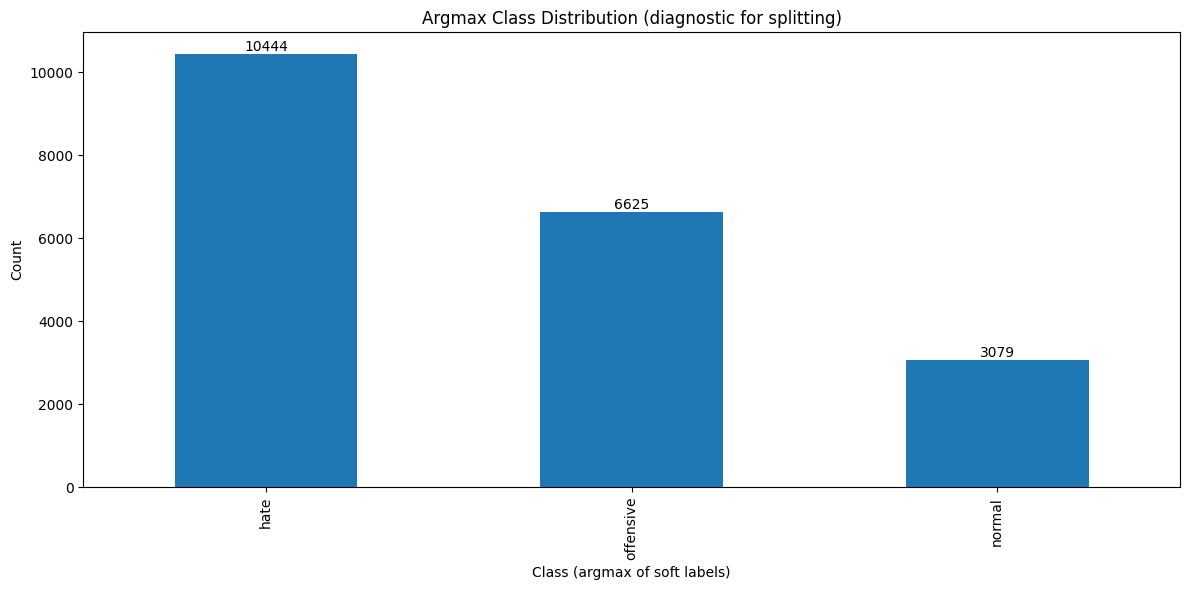

In [11]:
# --- Soft-label checks + derived hard label for splitting/plots ---
print("Validating soft labels...")
missing_cols = [c for c in SOFT_LABEL_COLUMNS if c not in df_clean.columns]
if missing_cols:
    raise ValueError(f"Missing soft-label columns in CSV: {missing_cols}")

# Ensure numeric
df_clean[SOFT_LABEL_COLUMNS] = df_clean[SOFT_LABEL_COLUMNS].apply(pd.to_numeric, errors="coerce")

# Basic validity checks
if df_clean[SOFT_LABEL_COLUMNS].isna().any().any():
    bad_rows = df_clean[df_clean[SOFT_LABEL_COLUMNS].isna().any(axis=1)].head(5)
    raise ValueError(f"Found NaNs in soft labels. Example rows:\n{bad_rows[SOFT_LABEL_COLUMNS]}")

# Clip tiny floating noise and check sums
probs = df_clean[SOFT_LABEL_COLUMNS].to_numpy(dtype=float)
if (probs < -1e-6).any() or (probs > 1 + 1e-6).any():
    raise ValueError("Soft labels contain values outside [0,1] (beyond tolerance).")

row_sums = probs.sum(axis=1)
if not np.allclose(row_sums, 1.0, atol=1e-3):
    # If needed, renormalize instead of failing:
    # probs = probs / row_sums[:, None]
    # df_clean[SOFT_LABEL_COLUMNS] = probs
    raise ValueError(
        f"Soft label rows do not sum to 1 within tolerance. "
        f"Example sums: {row_sums[:10]}"
    )

# Create a temporary hard label (argmax) ONLY for stratification/plotting
df_clean["y_hard_argmax"] = probs.argmax(axis=1)
df_clean["y_hard_name"] = df_clean["y_hard_argmax"].map({i: CLASS_NAMES[i] for i in range(N_CLASSES)})

print(f"Master 'df_clean' created with {df_clean.shape[0]} rows.")
print("Hard-label (argmax) distribution (for split diagnostics only):")
print(df_clean["y_hard_name"].value_counts())

# Plot imbalance (diagnostic only)
plt.figure(figsize=(12, 6))
status_counts = df_clean["y_hard_name"].value_counts()
ax = status_counts.plot(kind="bar")
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Argmax Class Distribution (diagnostic for splitting)")
plt.xlabel("Class (argmax of soft labels)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

### 2.3.1 Define groups for splitting

In [12]:
groups = df_clean[TEXT_COLUMN]          # prevent same cleaned text across splits
y_for_split = df_clean["y_hard_argmax"] # approx stratification signal (not training target)

### 2.3.2. First split: train vs test

In [13]:
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.array(["train"] * len(df_clean), dtype=object)
split[test_idx] = "test"
df_clean["split"] = split

print("After train/test split:")
print(df_clean["split"].value_counts())

After train/test split:
split
train    16122
test      4026
Name: count, dtype: int64


### 2.3.3. Second split: train -> train + val (within train only)

In [14]:
train_mask = df_clean["split"] == "train"
train_pos_indices = np.where(train_mask)[0]
df_train_only = df_clean.loc[train_mask].copy().reset_index(drop=True)

groups_train = df_train_only[TEXT_COLUMN]
y_train_for_split = df_train_only["y_hard_argmax"]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,  # 0.25 of train => 0.20 of full
    random_state=RANDOM_STATE,
)

train_idx2, val_idx = next(gss_val.split(df_train_only, y_train_for_split, groups=groups_train))

train2_global = train_pos_indices[train_idx2]
val_global = train_pos_indices[val_idx]

split[:] = "train"
split[val_global] = "val"
split[test_idx] = "test"
df_clean["split"] = split

print("\nFinal split counts:")
print(df_clean["split"].value_counts())


Final split counts:
split
train    12096
val       4026
test      4026
Name: count, dtype: int64


### 2.3.4. Sanity checks

In [15]:
# --- Leakage check: no text group appears in >1 split ---
group_split_counts = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky_groups = (group_split_counts > 1).sum()
print("\nNumber of text groups that appear in >1 split:", n_leaky_groups)
assert n_leaky_groups == 0, "Some text groups leak across splits!"

# --- Proportions ---
split_props = df_clean["split"].value_counts(normalize=True)
print("\nSplit proportions (approx):")
print(split_props)


Number of text groups that appear in >1 split: 0

Split proportions (approx):
split
train    0.600357
val      0.199821
test     0.199821
Name: proportion, dtype: float64


### 2.3.5. Save master split

In [16]:
split_path = os.path.join(DRIVE_PROJECT_PATH, "output/hatexplain_master_split_soft_4omini.csv")
df_clean.to_csv(split_path, index=False)
print("\nSaved master split to:", split_path)


Saved master split to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/hatexplain_master_split_soft_4omini.csv


# 3. ALBERT Model with Soft Labels


## 3.0 Define evaluation function for DL models

In [17]:
# --- Helper Function 1: F1 Score Bootstrapping ---
def bootstrap_f1_ci(y_true, y_pred, n_iterations = 1000, average = "weighted"):
    """Calculates the F1 score and 95% CI using bootstrapping."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1_scores = []

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        try:
            f1 = f1_score(y_true[indices], y_pred[indices], average = average)
            f1_scores.append(f1)
        except ValueError:
            continue  # Skip bootstrap sample if it's invalid

    if not f1_scores:
        return np.nan, np.nan, np.nan

    f1_mean = np.mean(f1_scores)
    ci_lower = np.percentile(f1_scores, 2.5)
    ci_upper = np.percentile(f1_scores, 97.5)
    return f1_mean, ci_lower, ci_upper


# --- Helper Function 2: Macro-AUC Bootstrapping ---
def bootstrap_auc_ci_multiclass(y_true, y_scores, n_iterations = 1000, average = "macro"):
    """Calculates the Macro-AUC and 95% CI using bootstrapping."""
    auc_scores = []
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))

        y_true_sample = y_true[indices]
        y_scores_sample = y_scores[indices]

        try:
            auc_sample = roc_auc_score(
                y_true_sample,
                y_scores_sample,
                average = average,
                multi_class = "ovr"
            )
            auc_scores.append(auc_sample)
        except ValueError:
            continue  # Skip bootstrap sample if it's missing a class

    if not auc_scores:
        return np.nan, np.nan, np.nan

    return (
        np.mean(auc_scores),
        np.percentile(auc_scores, 2.5),
        np.percentile(auc_scores, 97.5),
    )


def plot_confusion_matrix_named(y_true, y_pred, class_names, model_name="Model", save_dir=None, cmap_name="Blues"):
    n_classes = len(class_names)
    labels_idx = list(range(n_classes))
    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap_name,
        xticklabels=class_names, yticklabels=class_names,
        vmin=0, vmax=cm.max() if cm.size else 1
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved confusion matrix to: {path}")

    plt.show()


def plot_multiclass_roc_named(y_true, y_score, class_names, label_prefix="Model", save_dir=None):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    n_classes = len(class_names)

    classes_idx = np.arange(n_classes)  # IMPORTANT: y_true is int -> classes must be int
    y_true_bin = label_binarize(y_true, classes=classes_idx)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"{name} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{label_prefix}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved ROC curve to: {path}")

    plt.show()


# ---------- Main: reconstruct from disk + evaluate with CI ----------
def reconstruct_and_evaluate_best_albert_with_ci(
    model_path,
    params_path,
    test_texts,
    y_test_hard,
    class_names,
    max_len,
    batch_size=128,
    model_name="albert-base-v2",
    save_dir=None,
):
    device = get_device()

    # 1) load params (to reconstruct architecture identically)
    best_params_disk = None
    if params_path is not None and os.path.exists(str(params_path)):
        with open(str(params_path), "r") as f:
            best_params_disk = json.load(f)

    dropout = float(best_params_disk["dropout"]) if best_params_disk and "dropout" in best_params_disk else 0.1
    hidden_dim = best_params_disk.get("hidden_dim", None) if best_params_disk else None
    freeze_base = bool(best_params_disk.get("freeze_base", False)) if best_params_disk else False

    # 2) tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 3) reconstruct model + load state_dict
    model = AlbertClassifier(
        model_name=model_name,
        num_classes=len(class_names),
        dropout=dropout,
        hidden_dim=hidden_dim,
        freeze_base=freeze_base
    ).to(device)

    state = torch.load(str(model_path), map_location=device)
    model.load_state_dict(state)
    model.eval()

    print("Loaded model from:", str(model_path))
    print("Reconstructed with:", {"dropout": dropout, "hidden_dim": hidden_dim, "freeze_base": freeze_base})

    # 4) test loader
    test_ds = AlbertSoftDataset(
        test_texts, hard_labels=y_test_hard, soft_labels=None,
        tokenizer=tokenizer, max_len=max_len
    )
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # 5) logits -> probs -> preds
    test_logits, test_y, _ = predict_logits(model, test_loader, device=device)
    test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
    test_pred = np.argmax(test_probs, axis=1)

    # 6) Report (point estimates) + CI
    print(f"\n--- Evaluation Report: BEST_ALBERT_FROM_DISK ---\n")
    print("Classification Report:")
    print(
        classification_report(
            test_y,
            test_pred,
            labels=list(range(len(class_names))),
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    # F1 CI (your helper)
    f1_mean, f1_low, f1_high = bootstrap_f1_ci(test_y, test_pred, average="weighted")
    print(f"Weighted F1 Score: {f1_mean:.4f}")
    print(f"95% CI for F1 Score: [{f1_low:.4f}, {f1_high:.4f}]")

    # AUC CI (your helper expects y_scores = probs)
    auc_mean, auc_low, auc_high = bootstrap_auc_ci_multiclass(test_y, test_probs, average="macro")
    print(f"\nMacro-Averaged AUC: {auc_mean:.4f}")
    print(f"95% CI for Macro-Averaged AUC: [{auc_low:.4f}, {auc_high:.4f}]")

    # 7) Plots (saved)
    plot_confusion_matrix_named(test_y, test_pred, class_names, model_name="BEST_ALBERT_FROM_DISK", save_dir=save_dir)
    plot_multiclass_roc_named(test_y, test_probs, class_names, label_prefix="BEST_ALBERT_FROM_DISK", save_dir=save_dir)

    return {
        "y_true": np.asarray(test_y),
        "y_pred": np.asarray(test_pred),
        "y_prob": np.asarray(test_probs),
        "f1_weighted": float(f1_mean),
        "f1_ci": (float(f1_low), float(f1_high)),
        "auc_macro_ovr": float(auc_mean),
        "auc_ci": (float(auc_low), float(auc_high)),
        "reconstruct_params": {"dropout": dropout, "hidden_dim": hidden_dim, "freeze_base": freeze_base},
    }


## 3.1 Data Preprocessing

### Step 1: Build train/val/test splits for ALBERT

In [18]:
# Build split dfs
df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

### Step 2: Build texts + labels (soft train, hard val/test via argmax)

In [19]:
train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

def _get_soft(df: pd.DataFrame) -> np.ndarray:
    soft = df[SOFT_LABEL_COLUMNS].to_numpy(dtype=np.float32)
    soft = soft / np.clip(soft.sum(axis=1, keepdims=True), 1e-8, None)
    return soft

y_train_soft = _get_soft(df_train)  # [N,K]
y_val_soft   = _get_soft(df_val)    # useful for optional soft-metric
y_test_soft  = _get_soft(df_test)

y_val_hard   = y_val_soft.argmax(axis=1).astype(np.int64)
y_test_hard  = y_test_soft.argmax(axis=1).astype(np.int64)

print("Train soft shape:", y_train_soft.shape)
print("Val hard distribution:", np.bincount(y_val_hard, minlength=N_CLASSES))
print("Test hard distribution:", np.bincount(y_test_hard, minlength=N_CLASSES))

Train soft shape: (12096, 3)
Val hard distribution: [ 594 1319 2113]
Test hard distribution: [ 614 1376 2036]


## 3.2 Model Construction

### 3.2.1 Utilities: seed + device

In [20]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 3.2.2 Dataset

In [21]:
class AlbertSoftDataset(Dataset):
    """
    For training:
      returns input_ids, attention_mask, soft_labels [K], and hard_labels (argmax) for tracking.
    For val/test:
      returns input_ids, attention_mask, hard_labels (and optionally soft_labels if provided).
    """
    def __init__(self, texts, hard_labels=None, soft_labels=None, tokenizer=None, max_len=128):
        self.texts = list(texts)
        self.hard_labels = None if hard_labels is None else np.asarray(hard_labels, dtype=np.int64)
        self.soft_labels = None if soft_labels is None else np.asarray(soft_labels, dtype=np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

        if self.soft_labels is not None:
            # normalize
            rs = self.soft_labels.sum(axis=1, keepdims=True)
            self.soft_labels = self.soft_labels / np.clip(rs, 1e-8, None)

        if self.hard_labels is None and self.soft_labels is not None:
            self.hard_labels = self.soft_labels.argmax(axis=1).astype(np.int64)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.hard_labels is not None:
            item["labels"] = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        if self.soft_labels is not None:
            item["soft_labels"] = torch.tensor(self.soft_labels[idx], dtype=torch.float32)
        return item

### 3.2.3 Model

In [22]:
class AlbertClassifier(nn.Module):
    def __init__(self, model_name="albert-base-v2", num_classes=3, dropout=0.1, hidden_dim=None, freeze_base=False):
        super().__init__()
        self.base = AlbertModel.from_pretrained(model_name)
        hidden_size = self.base.config.hidden_size

        if freeze_base:
            for p in self.base.parameters():
                p.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        self.use_hidden = hidden_dim is not None

        if self.use_hidden:
            self.fc1 = nn.Linear(hidden_size, hidden_dim)
            self.act = nn.ReLU()
            self.fc2 = nn.Linear(hidden_dim, num_classes)
        else:
            self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # [B,H]
        x = self.dropout(cls)
        if self.use_hidden:
            x = self.fc1(x)
            x = self.act(x)
            x = self.dropout(x)
            logits = self.fc2(x)
        else:
            logits = self.fc(x)
        return logits


### 3.2.4 Losses + metrics

In [23]:
def soft_cross_entropy(logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
    log_probs = torch.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

def predict_logits(model, loader, device):
    model.eval()
    all_logits = []
    all_labels = []
    all_soft = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            logits = model(input_ids, attn)
            all_logits.append(logits.detach().cpu().numpy())
            if "labels" in batch:
                all_labels.append(batch["labels"].cpu().numpy())
            if "soft_labels" in batch:
                all_soft.append(batch["soft_labels"].cpu().numpy())
    logits_np = np.concatenate(all_logits, axis=0)
    labels_np = np.concatenate(all_labels, axis=0) if all_labels else None
    soft_np = np.concatenate(all_soft, axis=0) if all_soft else None
    return logits_np, labels_np, soft_np

def evaluate_from_logits(y_true_hard, logits, n_classes):
    preds = logits.argmax(axis=1)
    f1_weighted = f1_score(y_true_hard, preds, average="weighted")
    f1_macro = f1_score(y_true_hard, preds, average="macro")

    # Multiclass AUC (OVR). Needs probabilities.
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    try:
        auc_ovr = roc_auc_score(y_true_hard, probs, multi_class="ovr")
    except Exception:
        auc_ovr = np.nan

    return {
        "f1_weighted": float(f1_weighted),
        "f1_macro": float(f1_macro),
        "auc_ovr": float(auc_ovr),
    }

### 3.2.5 Train loop (soft train, hard-val early stopping on weighted F1)

In [24]:
def train_one_config(
    train_texts, y_train_soft,
    val_texts, y_val_hard,
    model_name="albert-base-v2",
    num_classes=3,
    max_len=128,
    batch_size=128,
    num_epochs=6,
    lr=2e-5,
    dropout=0.1,
    hidden_dim=None,
    freeze_base=False,
    patience=2,
    seed=42
):
    set_seed(seed)
    device = get_device()
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = AlbertSoftDataset(
        train_texts, hard_labels=None, soft_labels=y_train_soft,
        tokenizer=tokenizer, max_len=max_len
    )
    val_ds = AlbertSoftDataset(
        val_texts, hard_labels=y_val_hard, soft_labels=None,
        tokenizer=tokenizer, max_len=max_len
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = AlbertClassifier(
        model_name=model_name,
        num_classes=num_classes,
        dropout=dropout,
        hidden_dim=hidden_dim,
        freeze_base=freeze_base
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    ce_hard = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1w": []}
    best_val_f1 = -1.0
    best_state = None
    best_epoch = -1
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            soft = batch["soft_labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attn)
            loss = soft_cross_entropy(logits, soft)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = float(np.mean(losses))

        # val
        model.eval()
        val_losses = []
        all_val_logits = []
        all_val_y = []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attn = batch["attention_mask"].to(device)
                y = batch["labels"].to(device)
                logits = model(input_ids, attn)

                loss = ce_hard(logits, y)
                val_losses.append(loss.item())

                all_val_logits.append(logits.detach().cpu().numpy())
                all_val_y.append(y.detach().cpu().numpy())

        val_loss = float(np.mean(val_losses))
        val_logits = np.concatenate(all_val_logits, axis=0)
        val_y = np.concatenate(all_val_y, axis=0)
        val_metrics = evaluate_from_logits(val_y, val_logits, num_classes)
        val_f1w = val_metrics["f1_weighted"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1w"].append(val_f1w)

        print(f"Epoch {epoch}/{num_epochs} | TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | ValF1(w)={val_f1w:.4f}")

        if val_f1w > best_val_f1:
            best_val_f1 = val_f1w
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                print(f"Early stopping (no improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    best_metrics = {"best_val_f1_weighted": float(best_val_f1), "best_epoch": int(best_epoch)}
    return model, tokenizer, best_metrics, history


### 3.2.6 Random search over grid

In [25]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def soft_cross_entropy_torch(logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
    logp = torch.log_softmax(logits, dim=1)
    return -(soft_targets * logp).sum(dim=1).mean()


def random_hyperparameter_tuning_albert_soft_piece1_setup(
    train_texts, y_train_soft,
    val_texts, y_val_hard,
    n_iter,
    model_name="albert-base-v2",
    num_classes=3,
    max_len=128,
    batch_size=128,
    device=None,
    best_model_path=None,   # BEST_ALBERT_PATH
):
    """
    Soft-label training, but hyperparameter tuning setup is EXACTLY like Piece1:
      - same param_space
      - same sampling: lr log-uniform, epochs randint, dropout uniform
      - same tqdm loop
      - same best model saving (state_dict)
      - same evaluation: weighted F1 + accuracy on hard val labels
      - same class_weights computation style
    """

    if device is None:
        device = get_device()

    # Build datasets/loaders (use your existing AlbertSoftDataset)
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = AlbertSoftDataset(
        train_texts,
        hard_labels=None,
        soft_labels=y_train_soft,
        tokenizer=tokenizer,
        max_len=max_len
    )
    val_ds = AlbertSoftDataset(
        val_texts,
        hard_labels=y_val_hard,
        soft_labels=None,
        tokenizer=tokenizer,
        max_len=max_len
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)


    param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),  # 1e-5 to 3e-5
        "epochs": (3, 6),
        "dropout": (0.0, 0.25)
    }


    train_hard_from_soft = np.argmax(np.asarray(y_train_soft), axis=1).astype(np.int64)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_hard_from_soft),
        y=train_hard_from_soft
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    best_f1 = 0
    best_params = None
    best_model = None

    with tqdm(total=n_iter, desc="Random Search Tuning", leave=True) as pbar:
        for _ in range(n_iter):


            hyperparams = {
                "lr": 10 ** np.random.uniform(*param_space["lr"]),
                "epochs": np.random.randint(*param_space["epochs"]),
                "dropout": np.random.uniform(*param_space["dropout"]),
            }

            # Initialize model (keep your AlbertClassifier, but dropout matches sampled value)
            model = AlbertClassifier(
                model_name=model_name,
                num_classes=num_classes,
                dropout=float(hyperparams["dropout"]),
                hidden_dim=None,
                freeze_base=False
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=float(hyperparams["lr"]))
            ce_hard = nn.CrossEntropyLoss(weight=class_weights)  # for val loss / consistent weighting


            for epoch in range(int(hyperparams["epochs"])):
                model.train()
                for batch in train_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    soft = batch["soft_labels"].to(device)

                    optimizer.zero_grad()
                    logits = model(input_ids, attention_mask)
                    loss = soft_cross_entropy_torch(logits, soft)
                    loss.backward()
                    optimizer.step()


            model.eval()
            val_predictions, val_labels_batch = [], []
            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    logits = model(input_ids, attention_mask)
                    _ = ce_hard(logits, labels)  # keep same “have a criterion” pattern; not required for metrics
                    preds = torch.argmax(logits, dim=1)

                    val_predictions.extend(preds.cpu().numpy())
                    val_labels_batch.extend(labels.cpu().numpy())

            f1 = f1_score(val_labels_batch, val_predictions, average="weighted")
            accuracy = accuracy_score(val_labels_batch, val_predictions)

            # =========================
            # 8) BEST MODEL UPDATE + SAVE EXACTLY LIKE PIECE1
            # =========================
            if f1 > best_f1:
                best_f1 = f1
                best_params = hyperparams
                best_model = model
                if best_model_path is not None:
                    torch.save(model.state_dict(), best_model_path)

            pbar.set_postfix(f1=f1, accuracy=accuracy)
            pbar.update(1)

    print(f"\nBest F1 Score: {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")
    return best_params, best_f1, best_model, tokenizer


start_time = time.time()
best_params, best_f1, best_model, best_tokenizer = random_hyperparameter_tuning_albert_soft_piece1_setup(
    train_texts=train_texts,
    y_train_soft=y_train_soft,
    val_texts=val_texts,
    y_val_hard=y_val_hard,
    n_iter=N_ITERATIONS,
    model_name="albert-base-v2",
    num_classes=N_CLASSES,
    max_len=MAX_TOKEN_LENGTH,
    batch_size=128,
    device=get_device(),
    best_model_path=BEST_ALBERT_PATH
)
end_time = time.time()
print(f"Total Parameter Tuning Time: {end_time - start_time:.2f} seconds")

print("\nBest params:", best_params)

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Random Search Tuning:   0%|          | 0/10 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Random Search Tuning:  90%|█████████ | 9/10 [23:19<02:42, 162.23s/it, accuracy=0.741, f1=0.74]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Random Search Tuning: 100%|██████████| 10/10 [25:51<00:00, 155.10s/it, accuracy=0.74, f1=0.73]


Best F1 Score: 0.7472
Best Hyperparameters: {'lr': 2.4110256981852496e-05, 'epochs': 4, 'dropout': 0.13212463403019656}
Total Parameter Tuning Time: 1553.62 seconds

Best params: {'lr': 2.4110256981852496e-05, 'epochs': 4, 'dropout': 0.13212463403019656}


In [26]:
torch.save(best_model.state_dict(), str(BEST_ALBERT_PATH))

with open(BEST_ALBERT_PARAMS_PATH, "w") as f:
    json.dump(best_params, f, indent=2)

print(f"Saved model to: {BEST_ALBERT_PATH}")
print(f"Saved params to: {BEST_ALBERT_PARAMS_PATH}")

Saved model to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/best_albert_model_T51.pth
Saved params to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/best_albert_params_soft_4omini_T51.json


## 3.3 Predict + evaluate on test

In [27]:
device = get_device()

# ---- 1) Load best hyperparams from disk (to reconstruct same architecture) ----
best_params_disk = None
if BEST_ALBERT_PARAMS_PATH is not None and os.path.exists(BEST_ALBERT_PARAMS_PATH):
    with open(BEST_ALBERT_PARAMS_PATH, "r") as f:
        best_params_disk = json.load(f)

# Defaults match your tuning code if params file doesn't exist
dropout = float(best_params_disk["dropout"]) if best_params_disk and "dropout" in best_params_disk else 0.1
hidden_dim = best_params_disk.get("hidden_dim", None) if best_params_disk else None
freeze_base = bool(best_params_disk.get("freeze_base", False)) if best_params_disk else False

# ---- 2) Reconstruct model and load weights from disk ----
model_disk = AlbertClassifier(
    model_name="albert-base-v2",
    num_classes=N_CLASSES,
    dropout=dropout,
    hidden_dim=hidden_dim,      # should be None for your current tuning setup
    freeze_base=freeze_base     # should be False for your current tuning setup
).to(device)

state = torch.load(BEST_ALBERT_PATH, map_location=device)
model_disk.load_state_dict(state)
model_disk.eval()

print("Loaded model from:", BEST_ALBERT_PATH)
print("Reconstructed with:", {"dropout": dropout, "hidden_dim": hidden_dim, "freeze_base": freeze_base})

# ---- 3) Build test loader ----
test_ds = AlbertSoftDataset(
    test_texts,
    hard_labels=y_test_hard,
    soft_labels=None,
    tokenizer=best_tokenizer,          # tokenizer can be from training; if not, rebuild with AutoTokenizer
    max_len=MAX_TOKEN_LENGTH
)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

# ---- 4) Evaluate (your existing metric function) ----
test_logits, test_y, _ = predict_logits(model_disk, test_loader, device=device)
test_stats = evaluate_from_logits(test_y, test_logits, N_CLASSES)
print("\n[TEST] Metrics:", test_stats)

# ---- 5) Optional: probs if you need them ----
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model from: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/best_albert_model_T51.pth
Reconstructed with: {'dropout': 0.13212463403019656, 'hidden_dim': None, 'freeze_base': False}

[TEST] Metrics: {'f1_weighted': 0.7488903865640186, 'f1_macro': 0.6994102754296018, 'auc_ovr': 0.8894866682207749}


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model from: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/best_albert_model_T51.pth
Reconstructed with: {'dropout': 0.13212463403019656, 'hidden_dim': None, 'freeze_base': False}

--- Evaluation Report: BEST_ALBERT_FROM_DISK ---

Classification Report:
              precision    recall  f1-score   support

      normal     0.6659    0.4902    0.5647       614
   offensive     0.6593    0.7188    0.6878      1376
        hate     0.8380    0.8536    0.8457      2036

    accuracy                         0.7521      4026
   macro avg     0.7211    0.6875    0.6994      4026
weighted avg     0.7507    0.7521    0.7489      4026

Weighted F1 Score: 0.7491
95% CI for F1 Score: [0.7354, 0.7629]

Macro-Averaged AUC: 0.8892
95% CI for Macro-Averaged AUC: [0.8815, 0.8969]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/BEST_ALBERT_FROM_DISK_confusion_matrix.png


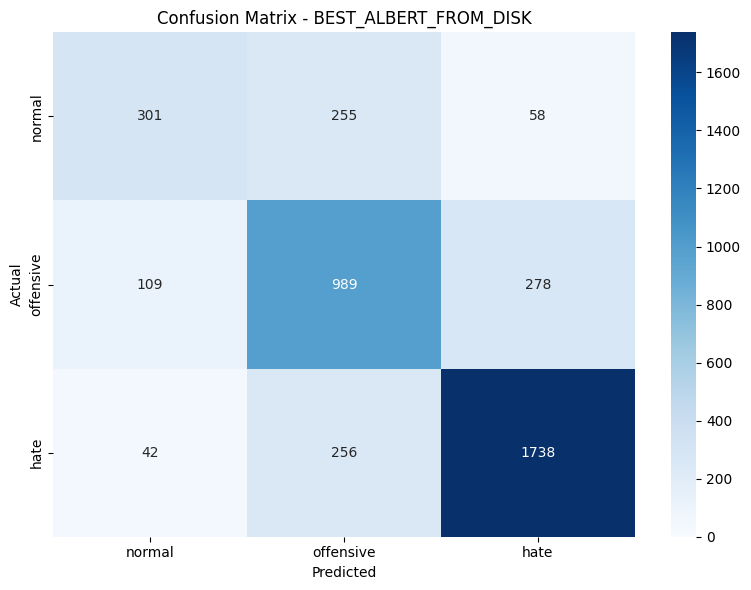

Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/12_4omini/output/BEST_ALBERT_FROM_DISK_roc_curve.png


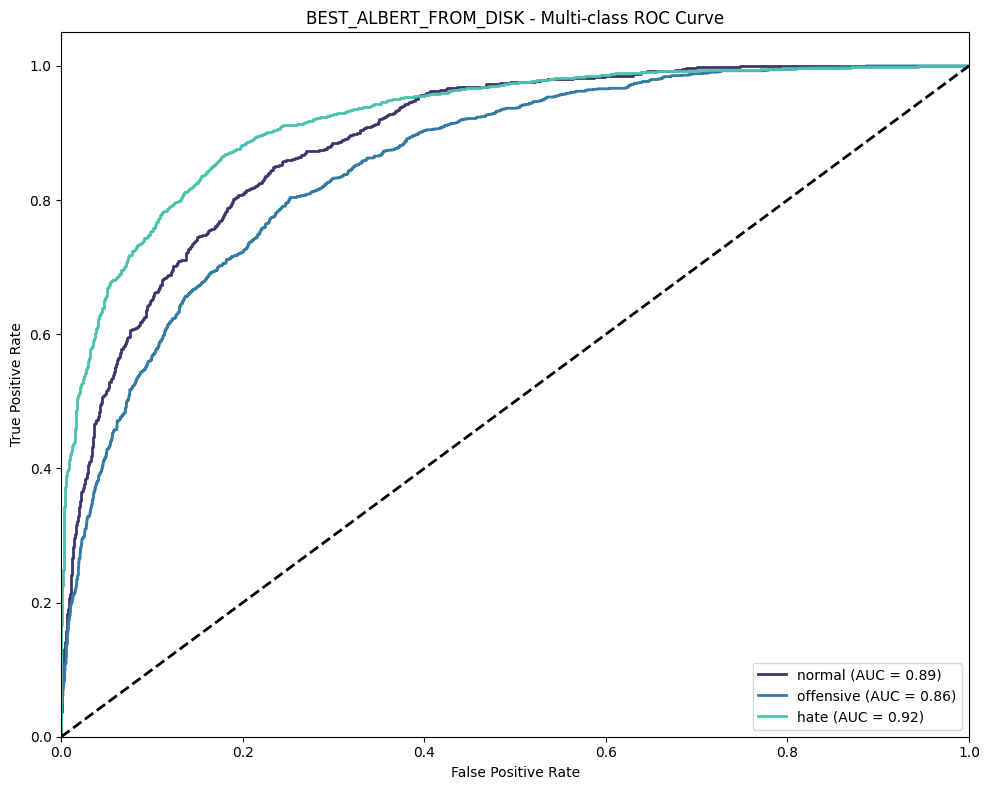


[TEST] Full Stats (with CI):
{'y_true': array([2, 2, 1, ..., 1, 2, 2]), 'y_pred': array([2, 2, 1, ..., 0, 2, 2]), 'y_prob': array([[1.1315906e-03, 7.8764483e-02, 9.2010397e-01],
       [2.9648529e-04, 8.4847838e-02, 9.1485566e-01],
       [3.2986153e-02, 8.5582173e-01, 1.1119215e-01],
       ...,
       [6.4763236e-01, 2.5384021e-01, 9.8527417e-02],
       [3.3743901e-03, 8.7260298e-02, 9.0936536e-01],
       [3.5549451e-02, 1.4277183e-01, 8.2167870e-01]], dtype=float32), 'f1_weighted': 0.749107864646417, 'f1_ci': (0.7353718007845552, 0.7629482077308157), 'auc_macro_ovr': 0.8892400791192387, 'auc_ci': (0.881493737854599, 0.8968629453601318), 'reconstruct_params': {'dropout': 0.13212463403019656, 'hidden_dim': None, 'freeze_base': False}}


In [28]:
save_dir = str(OUTPUT_PATH)  # you defined OUTPUT_PATH earlier

best_stats = reconstruct_and_evaluate_best_albert_with_ci(
    model_path=BEST_ALBERT_PATH,
    params_path=BEST_ALBERT_PARAMS_PATH,   # if you didn't save it, set to None
    test_texts=test_texts,
    y_test_hard=y_test_hard,
    class_names=CLASS_NAMES,               # ["normal","offensive","hate"]
    max_len=MAX_TOKEN_LENGTH,
    batch_size=128,
    model_name="albert-base-v2",
    save_dir=save_dir
)

print("\n[TEST] Full Stats (with CI):")
print(best_stats)